# 01 · Attrition Risk Prediction — Random Forest

**Goal** — generate an **attrition risk score** for every employee and flag the high-risk
ones for early HR intervention. The model learns from attendance patterns (`Absenteeism`,
`Average_Hours_Worked_Per_Week`), overtime (`Overtime`), performance trends
(`Performance_Rating`, `Job_Involvement`) and tenure (`Years_at_Company`,
`Years_Since_Last_Promotion`).

**Algorithm — Random Forest** (`RandomForestClassifier`). Chosen for its robustness to the
mixed, noisy, weakly-correlated HR features here, its insensitivity to feature scaling/outliers,
and the out-of-the-box feature-importance it gives HR. Rationale + citations in
`../MODEL-JUSTIFICATION.md`. Binary classification on
`employee_attrition_dataset_10000.csv` (~10k rows, ~20% leave).

Everything is logged to `logs/attrition*.log`; artifacts (model, metrics, plots, scored
roster) under `artifacts/attrition/`.

In [1]:
# --- environment & logged run -------------------------------------------------------
import sys
from pathlib import Path

# notebooks/ live one level below the model root where synapse_ml.py sits
HERE = Path.cwd()
MODEL_DIR = HERE if (HERE / "synapse_ml.py").exists() else HERE.parent
sys.path.insert(0, str(MODEL_DIR))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)

import synapse_ml as sm
run = sm.start_run("attrition")   # opens logs/attrition_<ts>.log + artifacts/attrition/
log = run.log

INFO    | ==============================================================================


INFO    | RUN START · model=attrition · 2026-06-23T03:18:34


INFO    | python=3.14.4 · platform=Windows-11-10.0.26200-SP0


INFO    | log file=C:\Users\Earl Kian\Documents\Project\synapse\model\logs\attrition_20260623_031834.log


INFO    | artifacts=C:\Users\Earl Kian\Documents\Project\synapse\model\artifacts\attrition


INFO    | libs · numpy=2.5.0, pandas=2.3.3, scipy=1.18.0, sklearn=1.9.0, matplotlib=3.11.0, seaborn=0.13.2


## 1 · Load data

In [2]:
df = run.load_csv("employee_attrition_dataset_10000.csv")
print(df.shape)
df.head()

INFO    | loading data · C:\Users\Earl Kian\Documents\Project\synapse\model\employee_attrition_dataset_10000.csv


INFO    | loaded shape=(10000, 26) · columns=26


(10000, 26)


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,12,3,1,3,2,74,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,7,5,1,2,2,24,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,4,3,4,5,1,63,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,9,1,1,1,2,4,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,9,1,3,4,3,62,No,1,54,11,1,1,1,43,4,No


In [3]:
import io
_info = io.StringIO()
df.info(buf=_info)
log.info("dataframe info:\n%s", _info.getvalue())
df.describe(include="all").T

INFO    | dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              1000

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Age,10000.0,NaN,NaN,NaN,39.5618,11.454986,20.0,30.0,40.0,49.0,59.0
Gender,10000,2,Female,5042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,10000,3,Married,3375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,10000,5,Marketing,2133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Role,10000,4,Analyst,2572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Level,10000.0,NaN,NaN,NaN,2.9908,1.410643,1.0,2.0,3.0,4.0,5.0
Monthly_Income,10000.0,NaN,NaN,NaN,11436.7167,4926.528302,3000.0,7182.5,11401.5,15679.5,19999.0
Hourly_Rate,10000.0,NaN,NaN,NaN,57.0323,24.703261,15.0,36.0,57.0,78.0,99.0
Years_at_Company,10000.0,NaN,NaN,NaN,14.9362,8.431657,1.0,8.0,15.0,22.0,29.0


## 2 · Target & exploratory analysis

INFO    | target=Attrition · positive rate=0.200 (1997 of 10000)


INFO    | saved figure · 01_class_balance.png


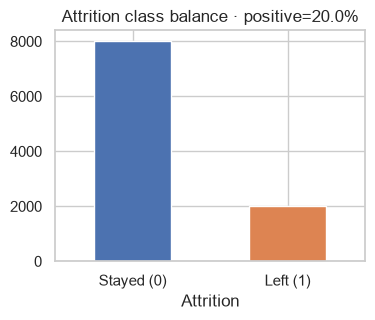

In [4]:
TARGET = "Attrition"
ID_COL = "Employee_ID"

y = (df[TARGET].astype(str).str.strip().str.lower() == "yes").astype(int)
rate = y.mean()
log.info("target=%s · positive rate=%.3f (%d of %d)", TARGET, rate, y.sum(), len(y))

fig, ax = plt.subplots(figsize=(4, 3))
y.value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_xticklabels(["Stayed (0)", "Left (1)"], rotation=0)
ax.set_title(f"Attrition class balance · positive={rate:.1%}")
run.save_fig(fig, "01_class_balance"); plt.show()

INFO    | attrition rate by Overtime:
Overtime
Yes    0.200735
No     0.198707


INFO    | attrition rate by Job_Satisfaction:
Job_Satisfaction
4    0.221563
2    0.205128
3    0.193148
1    0.191710
5    0.187140


INFO    | attrition rate by Department:
Department
Finance      0.208543
IT           0.203549
Sales        0.198207
HR           0.195084
Marketing    0.193624


INFO    | saved figure · 02_attrition_by_driver.png


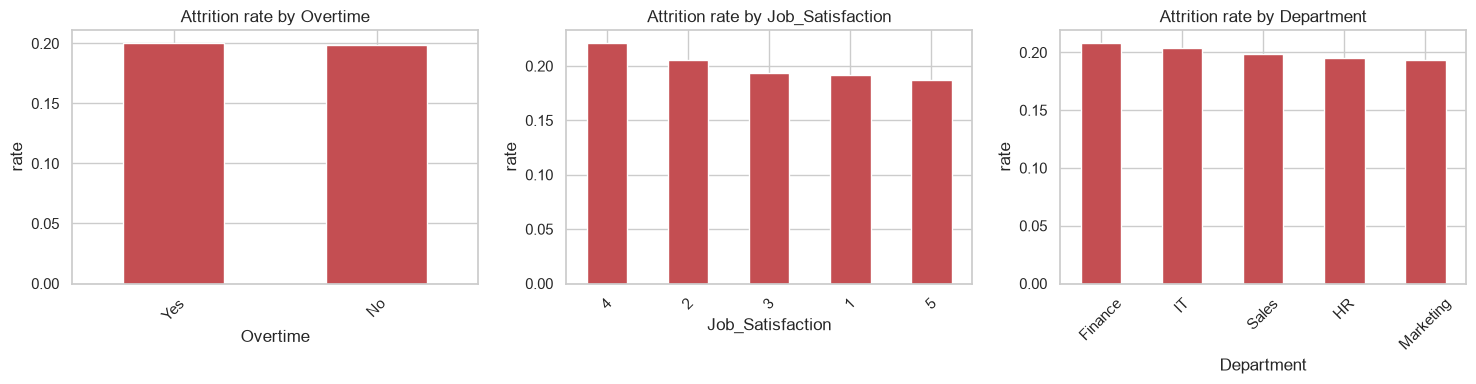

In [5]:
# Attrition rate across the drivers the model is meant to read.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Overtime", "Job_Satisfaction", "Department"]):
    rates = df.assign(_y=y).groupby(col)["_y"].mean().sort_values(ascending=False)
    log.info("attrition rate by %s:\n%s", col, rates.to_string())
    rates.plot(kind="bar", ax=ax, color="#c44e52")
    ax.set_title(f"Attrition rate by {col}"); ax.set_ylabel("rate")
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout(); run.save_fig(fig, "02_attrition_by_driver"); plt.show()

INFO    | numeric correlation with attrition:
Work_Environment_Satisfaction   -0.011096
Number_of_Companies_Worked      -0.008230
Hourly_Rate                     -0.005494
Relationship_with_Manager       -0.004111
Average_Hours_Worked_Per_Week   -0.002457
Years_Since_Last_Promotion      -0.001936
Training_Hours_Last_Year        -0.000539
Monthly_Income                   0.000135
Absenteeism                      0.000514
Job_Satisfaction                 0.002142
Years_at_Company                 0.002682
Years_in_Current_Role            0.005120
Project_Count                    0.006802
Age                              0.007798
Distance_From_Home               0.011361
Job_Level                        0.011415
Performance_Rating               0.011856
Job_Involvement                  0.014954
Work_Life_Balance                0.015227


INFO    | saved figure · 03_numeric_correlation.png


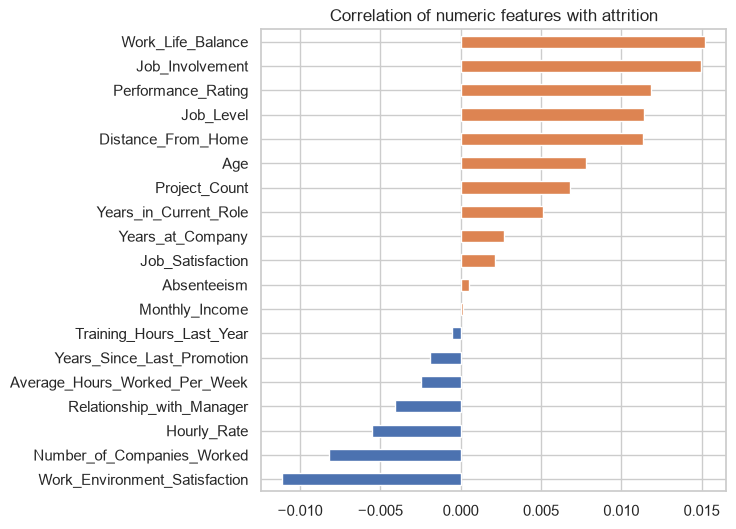

In [6]:
num_df = df.drop(columns=[ID_COL, TARGET]).select_dtypes("number").assign(_attr=y)
corr = num_df.corr()["_attr"].drop("_attr").sort_values()
log.info("numeric correlation with attrition:\n%s", corr.to_string())

fig, ax = plt.subplots(figsize=(6, 6))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#dd8452", "#4c72b0"))
ax.set_title("Correlation of numeric features with attrition")
run.save_fig(fig, "03_numeric_correlation"); plt.show()

## 3 · Preprocessing & stratified split

A `ColumnTransformer` median-imputes + scales numerics and mode-imputes + one-hot-encodes
categoricals. (Random Forests don't need scaling, but a single shared recipe keeps the three
notebooks consistent and harmless here.) Stratified split preserves the ~20% leave rate.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df.drop(columns=[TARGET, ID_COL])
numeric_cols, categorical_cols = sm.split_feature_types(df.drop(columns=[ID_COL]), target=TARGET)
log.info("numeric=%d %s", len(numeric_cols), numeric_cols)
log.info("categorical=%d %s", len(categorical_cols), categorical_cols)

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), numeric_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]),
     categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
log.info("split · train=%s test=%s", X_train.shape, X_test.shape)

INFO    | numeric=19 ['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']


INFO    | categorical=5 ['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']


INFO    | split · train=(8000, 24) test=(2000, 24)


## 4 · Random Forest model

`class_weight="balanced_subsample"` re-weights each bootstrap to counter the imbalance.
Quality is read from 5-fold ROC-AUC before the final fit on all training data.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=2,
        max_features="sqrt", class_weight="balanced_subsample",
        n_jobs=-1, random_state=42)),
])

cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
log.info("CV ROC-AUC = %.4f (+/- %.4f)", cv_auc.mean(), cv_auc.std())
model.fit(X_train, y_train)
log.info("fitted RandomForest on %d rows", len(X_train))

INFO    | CV ROC-AUC = 0.5028 (+/- 0.0183)


INFO    | fitted RandomForest on 8000 rows


## 5 · Evaluation

In [9]:
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
roc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
report = classification_report(y_test, pred, target_names=["Stayed", "Left"], digits=3)
log.info("test ROC-AUC=%.4f · PR-AUC=%.4f", roc, pr_auc)
log.info("classification report @0.5:\n%s", report)
print(report)

INFO    | test ROC-AUC=0.4875 · PR-AUC=0.2047


INFO    | classification report @0.5:
              precision    recall  f1-score   support

      Stayed      0.800     1.000     0.889      1601
        Left      0.000     0.000     0.000       399

    accuracy                          0.800      2000
   macro avg      0.400     0.500     0.445      2000
weighted avg      0.641     0.800     0.712      2000



              precision    recall  f1-score   support

      Stayed      0.800     1.000     0.889      1601
        Left      0.000     0.000     0.000       399

    accuracy                          0.800      2000
   macro avg      0.400     0.500     0.445      2000
weighted avg      0.641     0.800     0.712      2000



C:\Users\Earl Kian\Documents\Project\synapse\model\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Earl Kian\Documents\Project\synapse\model\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Earl Kian\Documents\Project\synapse\model\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

INFO    | saved figure · 04_evaluation_curves.png


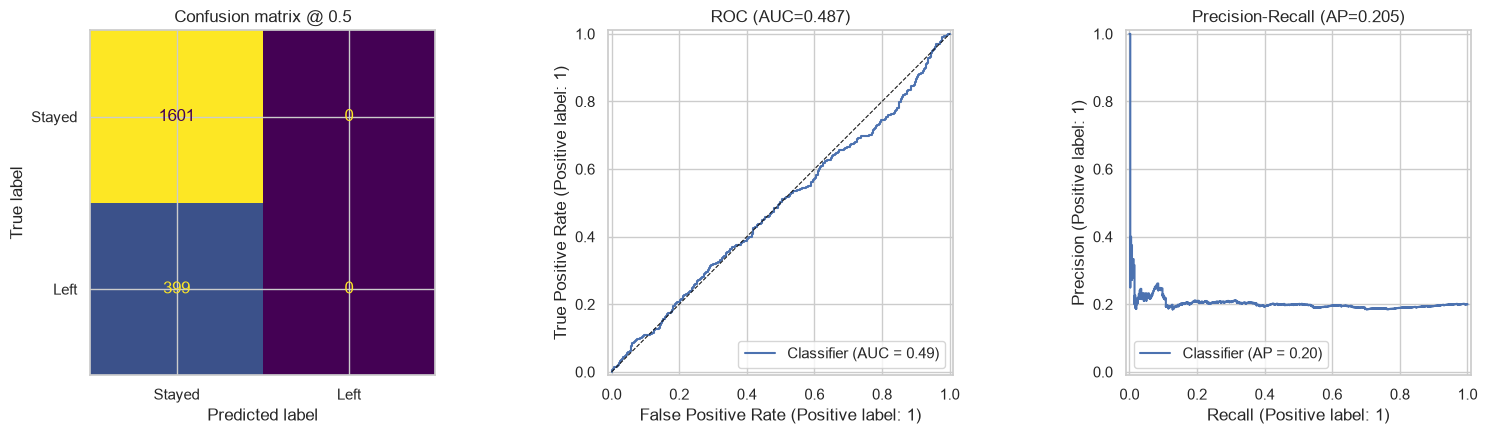

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Stayed", "Left"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix @ 0.5")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1])
axes[1].set_title(f"ROC (AUC={roc:.3f})"); axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2])
axes[2].set_title(f"Precision-Recall (AP={pr_auc:.3f})")
fig.tight_layout(); run.save_fig(fig, "04_evaluation_curves"); plt.show()

INFO    | top RF feature importances:
Monthly_Income                   0.075969
Training_Hours_Last_Year         0.068994
Hourly_Rate                      0.068146
Distance_From_Home               0.064489
Age                              0.061399
Average_Hours_Worked_Per_Week    0.058899
Years_at_Company                 0.058321
Absenteeism                      0.053616
Years_in_Current_Role            0.048276
Years_Since_Last_Promotion       0.043159
Project_Count                    0.041432
Job_Satisfaction                 0.030187
Job_Level                        0.029601
Relationship_with_Manager        0.025905
Work_Environment_Satisfaction    0.025778


INFO    | saved figure · 05_feature_importance.png


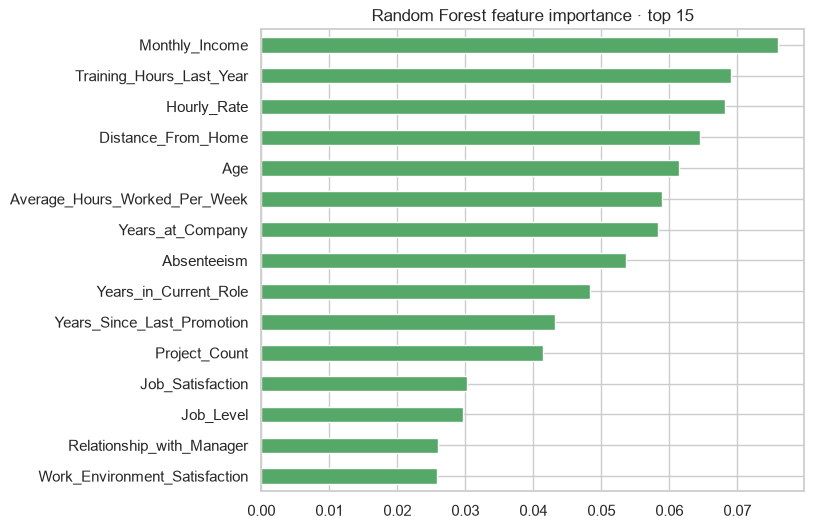

In [11]:
# Random Forest impurity importances (native) — what drives the risk score.
ohe = model.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
feat_names = numeric_cols + list(ohe.get_feature_names_out(categorical_cols))
importances = pd.Series(model.named_steps["clf"].feature_importances_, index=feat_names)
top = importances.sort_values().tail(15)
log.info("top RF feature importances:\n%s", top.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(7, 6))
top.plot(kind="barh", ax=ax, color="#55a868")
ax.set_title("Random Forest feature importance · top 15")
run.save_fig(fig, "05_feature_importance"); plt.show()

## 6 · Decision-threshold tuning

Missing a leaver (false negative) is the costly error, so we pick the threshold maximising F1
on the "Left" class instead of defaulting to 0.5.

INFO    | tuned threshold=0.175 · F1=0.335 · recall=0.990 · precision=0.201


              precision    recall  f1-score   support

      Stayed      0.895     0.021     0.041      1601
        Left      0.201     0.990     0.335       399

    accuracy                          0.214      2000
   macro avg      0.548     0.506     0.188      2000
weighted avg      0.756     0.214     0.100      2000

INFO    | saved figure · 06_threshold_sweep.png


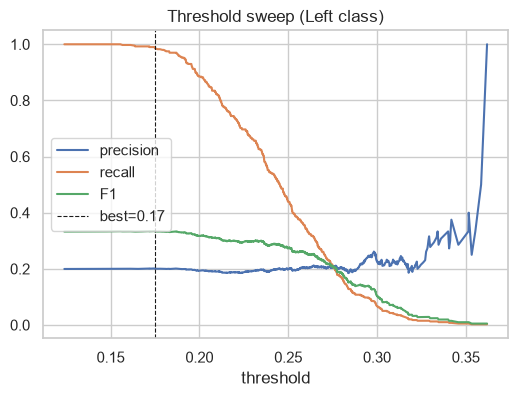

In [12]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, proba)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1s[:-1]))
best_thr = float(thr[best_idx])
log.info("tuned threshold=%.3f · F1=%.3f · recall=%.3f · precision=%.3f",
         best_thr, f1s[best_idx], rec[best_idx], prec[best_idx])
print(classification_report(y_test, (proba >= best_thr).astype(int),
                            target_names=["Stayed", "Left"], digits=3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr, prec[:-1], label="precision"); ax.plot(thr, rec[:-1], label="recall")
ax.plot(thr, f1s[:-1], label="F1")
ax.axvline(best_thr, color="k", ls="--", lw=0.8, label=f"best={best_thr:.2f}")
ax.set_xlabel("threshold"); ax.set_title("Threshold sweep (Left class)"); ax.legend()
run.save_fig(fig, "06_threshold_sweep"); plt.show()

## 7 · Risk scoring & high-risk flags

The headline deliverable: turn probabilities into a 0–100 **attrition risk score** and bucket
employees into Low / Medium / High tiers for HR. The scored test roster is checkpointed to
`artifacts/attrition/`.

In [13]:
scored = X_test.copy()
scored["risk_score"] = (proba * 100).round(1)
scored["actual_attrition"] = y_test.values
scored["risk_tier"] = pd.cut(proba, bins=[-0.01, 0.33, 0.66, 1.01],
                             labels=["Low", "Medium", "High"])
tier_counts = scored["risk_tier"].value_counts().sort_index()
log.info("risk tier distribution:\n%s", tier_counts.to_string())

high_risk = scored.sort_values("risk_score", ascending=False).head(10)
log.info("top-10 highest-risk employees:\n%s",
         high_risk[["risk_score", "risk_tier", "actual_attrition"]].to_string())
run.checkpoint_df(scored.reset_index(names="row_id"), "scored_test_roster")
high_risk[["risk_score", "risk_tier", "actual_attrition"]]

INFO    | risk tier distribution:
risk_tier
Low       1983
Medium      17
High         0


INFO    | top-10 highest-risk employees:
      risk_score risk_tier  actual_attrition
9695        36.2    Medium                 1
1894        35.9    Medium                 0
4718        35.5    Medium                 0
1224        35.3    Medium                 0
5612        35.2    Medium                 1
3750        35.1    Medium                 0
4392        34.6    Medium                 0
186         34.2    Medium                 1
5025        34.1    Medium                 0
1590        34.1    Medium                 0


WARNING | parquet unavailable (Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.); wrote CSV instead


INFO    | checkpoint dataframe · scored_test_roster.csv · shape=(2000, 28)


,risk_score,risk_tier,actual_attrition
9695,36.2,Medium,1
1894,35.9,Medium,0
4718,35.5,Medium,0
1224,35.3,Medium,0
5612,35.2,Medium,1
3750,35.1,Medium,0
4392,34.6,Medium,0
186,34.2,Medium,1
5025,34.1,Medium,0
1590,34.1,Medium,0


## 8 · Persist model & metrics

In [14]:
run.save_model(model, "attrition_model")
run.save_metrics({
    "algorithm": "RandomForestClassifier",
    "cv_roc_auc": float(cv_auc.mean()),
    "test_roc_auc": roc,
    "test_pr_auc": pr_auc,
    "tuned_threshold": best_thr,
    "tuned_recall_left": float(rec[best_idx]),
    "tuned_precision_left": float(prec[best_idx]),
    "positive_rate": float(rate),
    "high_risk_count": int((scored["risk_tier"] == "High").sum()),
    "n_train": int(len(X_train)), "n_test": int(len(X_test)),
})
run.finish(summary=f"RandomForest: test ROC-AUC={roc:.3f}, PR-AUC={pr_auc:.3f}, tuned thr={best_thr:.2f}")

INFO    | saved model · attrition_model.joblib (91415.8 KB)


INFO    | saved metrics · metrics.json


INFO    |   algorithm                    = RandomForestClassifier


INFO    |   cv_roc_auc                   = 0.5028


INFO    |   test_roc_auc                 = 0.4875


...

INFO    |   n_train                      = 8000.0000


INFO    |   n_test                       = 2000.0000


INFO    | summary · RandomForest: test ROC-AUC=0.487, PR-AUC=0.205, tuned thr=0.17


INFO    | RUN END · model=attrition · elapsed=10.8s


INFO    | ==============================================================================
